In [1]:
# Example: Predict 30-Day Patient Readmission
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
data = {
    "age": [72, 55, 63, 80, 45, 68, 77, 59],
    "prior_admissions": [3, 1, 2, 4, 0, 3, 5, 1],
    "length_of_stay": [7, 3, 5, 10, 2, 6, 9, 4],
    "discharge_notes": [
        "Patient lives alone and has difficulty managing medications.",
        "Discharged in stable condition, no complications.",
        "Follow-up adherence uncertain, limited social support.",
        "Multiple comorbidities and frequent prior admissions.",
        "Young patient, good recovery, no concerns.",
        "Chronic condition with medication non-compliance.",
        "High risk due to repeated hospitalizations and frailty.",
        "Stable vitals, routine discharge."
    ],
    "readmitted_30d": [1, 0, 1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

In [3]:
df

,age,prior_admissions,length_of_stay,discharge_notes,readmitted_30d
0,72,3,7,Patient lives alone and has difficulty managin...,1
1,55,1,3,"Discharged in stable condition, no complications.",0
2,63,2,5,"Follow-up adherence uncertain, limited social ...",1
3,80,4,10,Multiple comorbidities and frequent prior admi...,1
4,45,0,2,"Young patient, good recovery, no concerns.",0
5,68,3,6,Chronic condition with medication non-compliance.,1
6,77,5,9,High risk due to repeated hospitalizations and...,1
7,59,1,4,"Stable vitals, routine discharge.",0


In [4]:
X = df.drop(columns="readmitted_30d")
y = df["readmitted_30d"]

In [5]:
numeric_features = ["age", "prior_admissions", "length_of_stay"]
text_feature = "discharge_notes"

In [6]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=50,
        ngram_range=(1, 2),
        stop_words="english"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("text", text_transformer, text_feature)
    ]
)

In [7]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

log_reg_model.fit(X_train, y_train)

y_pred_prob = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression AUC:",
      roc_auc_score(y_test, y_pred_prob))


Logistic Regression AUC: 1.0


In [8]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier())
])

gb_model.fit(X_train, y_train)

y_pred_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting AUC:",
      roc_auc_score(y_test, y_pred_prob_gb))


Gradient Boosting AUC: 1.0


In [9]:
y_pred = gb_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Coefficient (slope): 0.6
Intercept: 2.2
Predictions: [5.8 6.4]


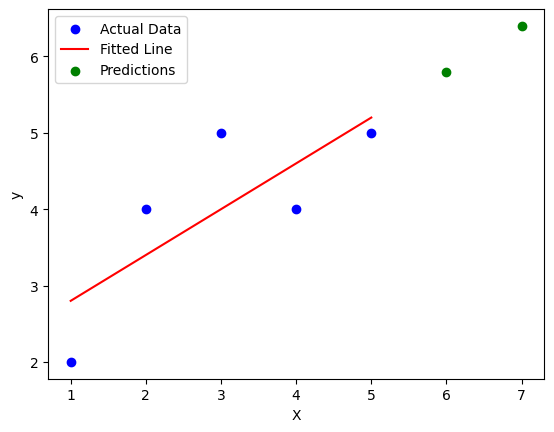

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

#Example data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Reshape for sklearn
y = np.array([2, 4, 5, 4, 5])
 
# Create and train the model
model = LinearRegression()
model.fit(X, y)
 
# Make predictions
X_test = np.array([6, 7]).reshape(-1, 1)
predictions = model.predict(X_test)
 
# Output the coefficients and intercept
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("Predictions:", predictions)
 
# Plot the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Fitted Line')
plt.scatter(X_test, predictions, color='green', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [24]:
p = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
p.shape

(5, 1)

Predictions: [5. 5.]


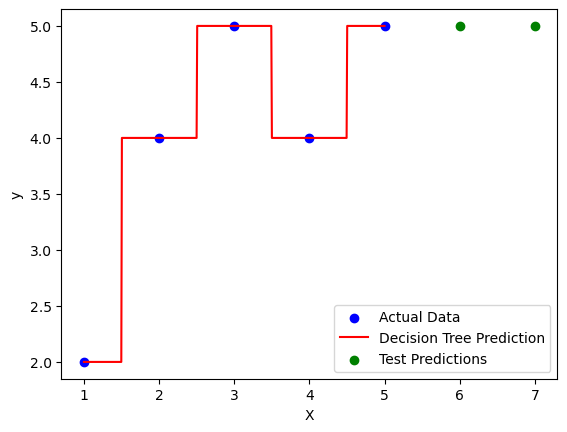

In [25]:

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
 
# Example data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Reshape for sklearn
y = np.array([2, 4, 5, 4, 5])
 
# Create and train the model
model = DecisionTreeRegressor()
model.fit(X, y)
 
# Make predictions
X_test = np.array([6, 7]).reshape(-1, 1)
predictions = model.predict(X_test)
 
# Output the predictions
print("Predictions:", predictions)
 
# Plot the results
plt.scatter(X, y, color='blue', label='Actual Data')
X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_range_pred = model.predict(X_range)
plt.plot(X_range, y_range_pred, color='red', label='Decision Tree Prediction')
plt.scatter(X_test, predictions, color='green', label='Test Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()